In [1]:
# importing the python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
# loading the cleaned dataset produced at the end of Data_cleaning.ipynb
cleaned_customer_transaction_data = pd.read_csv("../Finlora_Dataset/artifacts/Cleaned_Data.csv")
cleaned_customer_transaction_data.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0.0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0.0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0.0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0.0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0.0,0,0.0,0


In [3]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette='Spectral'
)

In [9]:
cleaned_customer_transaction_data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

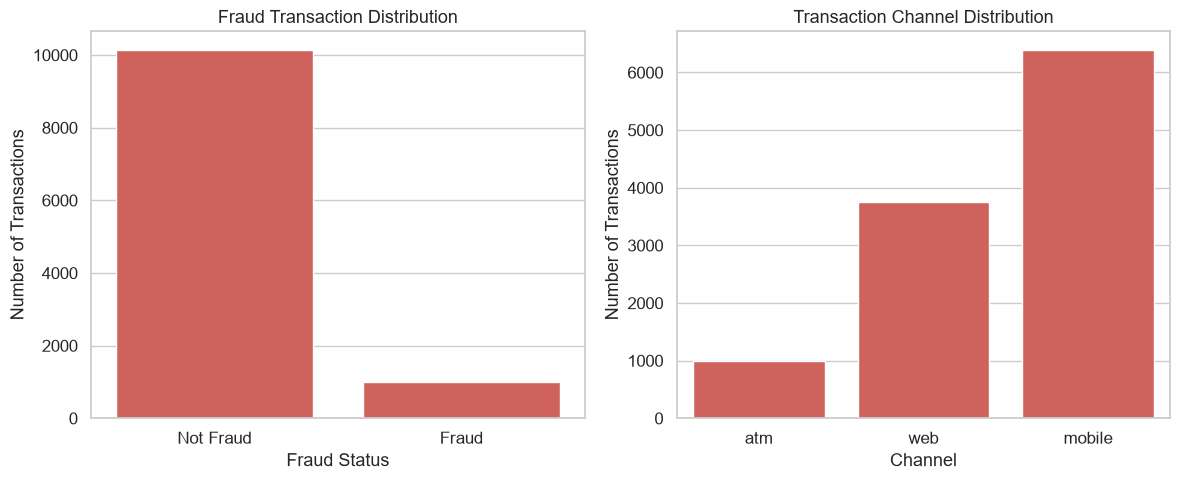

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud distribution
sns.countplot(data=cleaned_customer_transaction_data, x='is_fraud', ax=axes[0])
axes[0].set_title('Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

# Channel distribution
sns.countplot(data=cleaned_customer_transaction_data, x='channel', ax=axes[1])
axes[1].set_title('Transaction Channel Distribution')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

## Distribution of Fraud and Transaction Channels

The two charts above give an initial view of `cleaned_customer_transaction_data`, an important first step in EDA. The **fraud distribution chart** examines the balance between fraudulent and legitimate transactions in the `is_fraud` target column. This matters for fraud detection because a heavily imbalanced target can push a model to just favour the majority class and perform poorly at catching actual fraud. Seeing the scale of that imbalance up front determines whether techniques like class weighting or resampling (SMOTE) will be needed later.

The **transaction channel distribution chart** shows how transactions split across the `channel` column's categories (`atm`, `web`, `mobile`). This flags whether any channel dominates or is underrepresented, and gives an early signal on whether channel is worth investigating as a fraud-related feature.

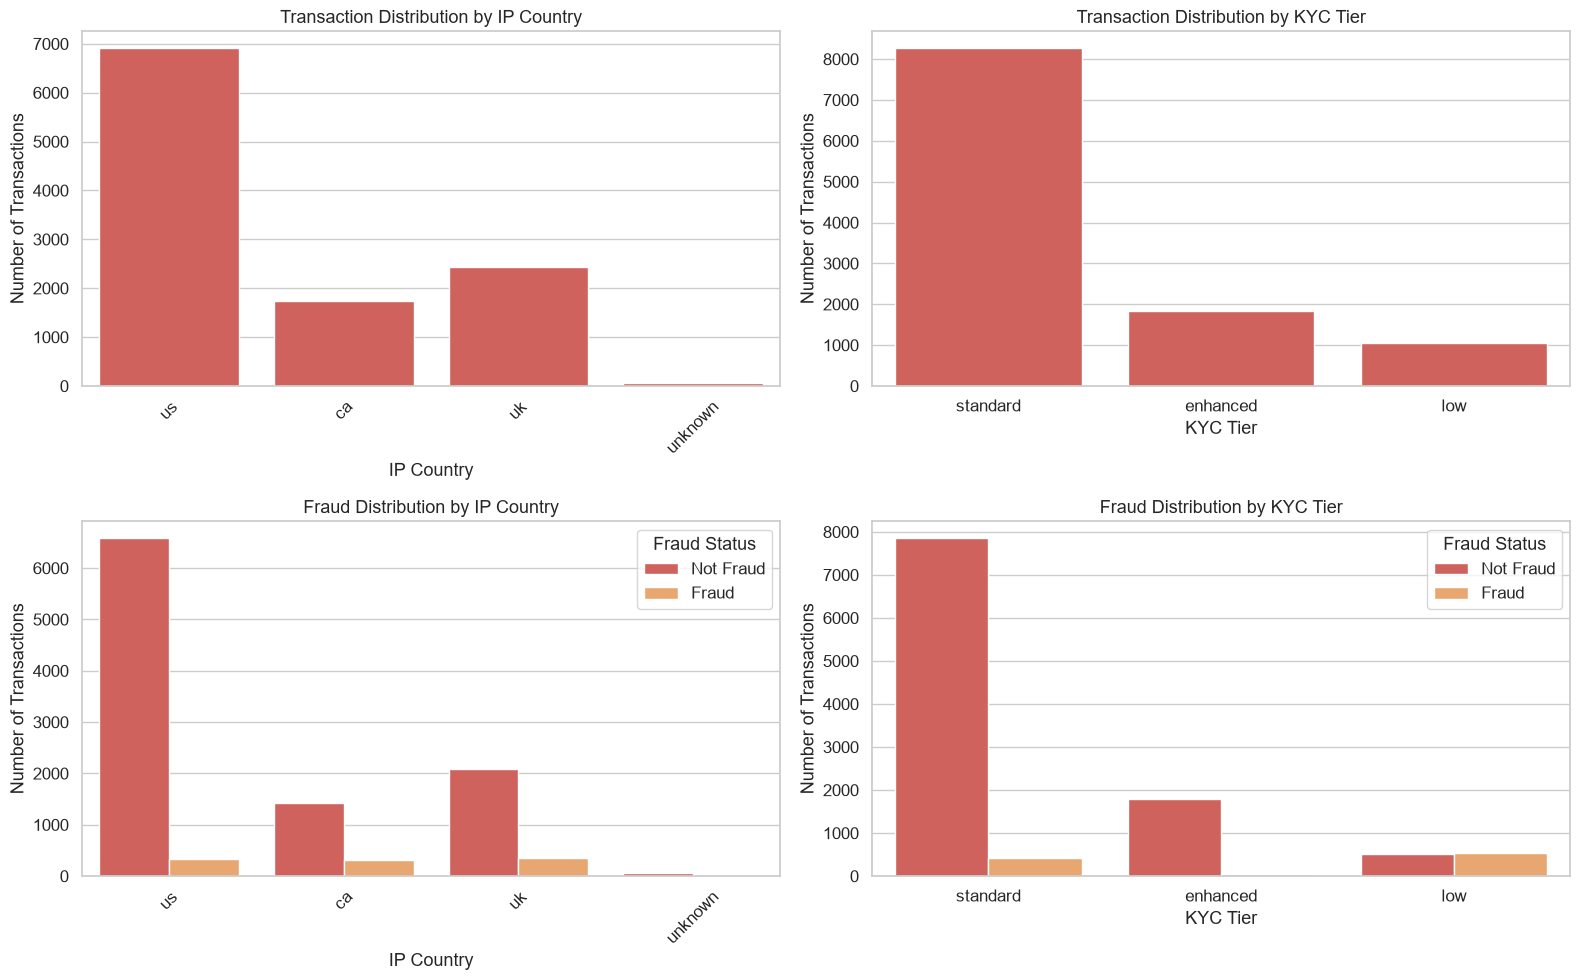

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. KYC Tier distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions')

# 3. IP Country vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    hue='is_fraud',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Fraud Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

# 4. KYC Tier vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    hue='is_fraud',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

### IP Country and KYC Tier Analysis

The four charts above give an overview of how transactions distribute across `ip_country` and `kyc_tier`, and how each relates to `is_fraud`. The **IP country distribution** shows which countries transactions are predominantly initiated from, including the `'unknown'` category preserved during cleaning for cases where IP-based location could not be determined. The **KYC tier distribution** shows the split across customer verification levels, giving a picture of how the customer base is composed.

The **IP country versus fraud** chart compares fraud rates across countries. This helps flag whether fraud concentrates in particular locations, though raw counts should be read carefully since countries with more total transactions will naturally show more fraud cases in absolute terms, not necessarily a higher rate.

The **KYC tier versus fraud** chart checks whether fraud occurrence varies by verification level, which would indicate `kyc_tier` carries useful predictive signal for the model.

Together, these charts point to whether customer verification level and transaction origin are worth carrying into feature engineering.

**Key observation:** `kyc_tier` shows a strong relationship with fraud. The low-verification tier has a fraud rate roughly 8-9x higher than the standard tier, and noticeably higher than the enhanced tier, which shows almost no fraud. This makes `kyc_tier` a likely useful feature for the fraud detection model. `ip_country`, by contrast, shows a much weaker signal: fraud counts stay roughly proportional to transaction volume across `us`, `ca`, and `uk`, with no country standing out as disproportionately fraud-heavy.

C:\Users\hp\AppData\Local\Temp\ipykernel_13748\836789288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13748\836789288.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13748\836789288.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


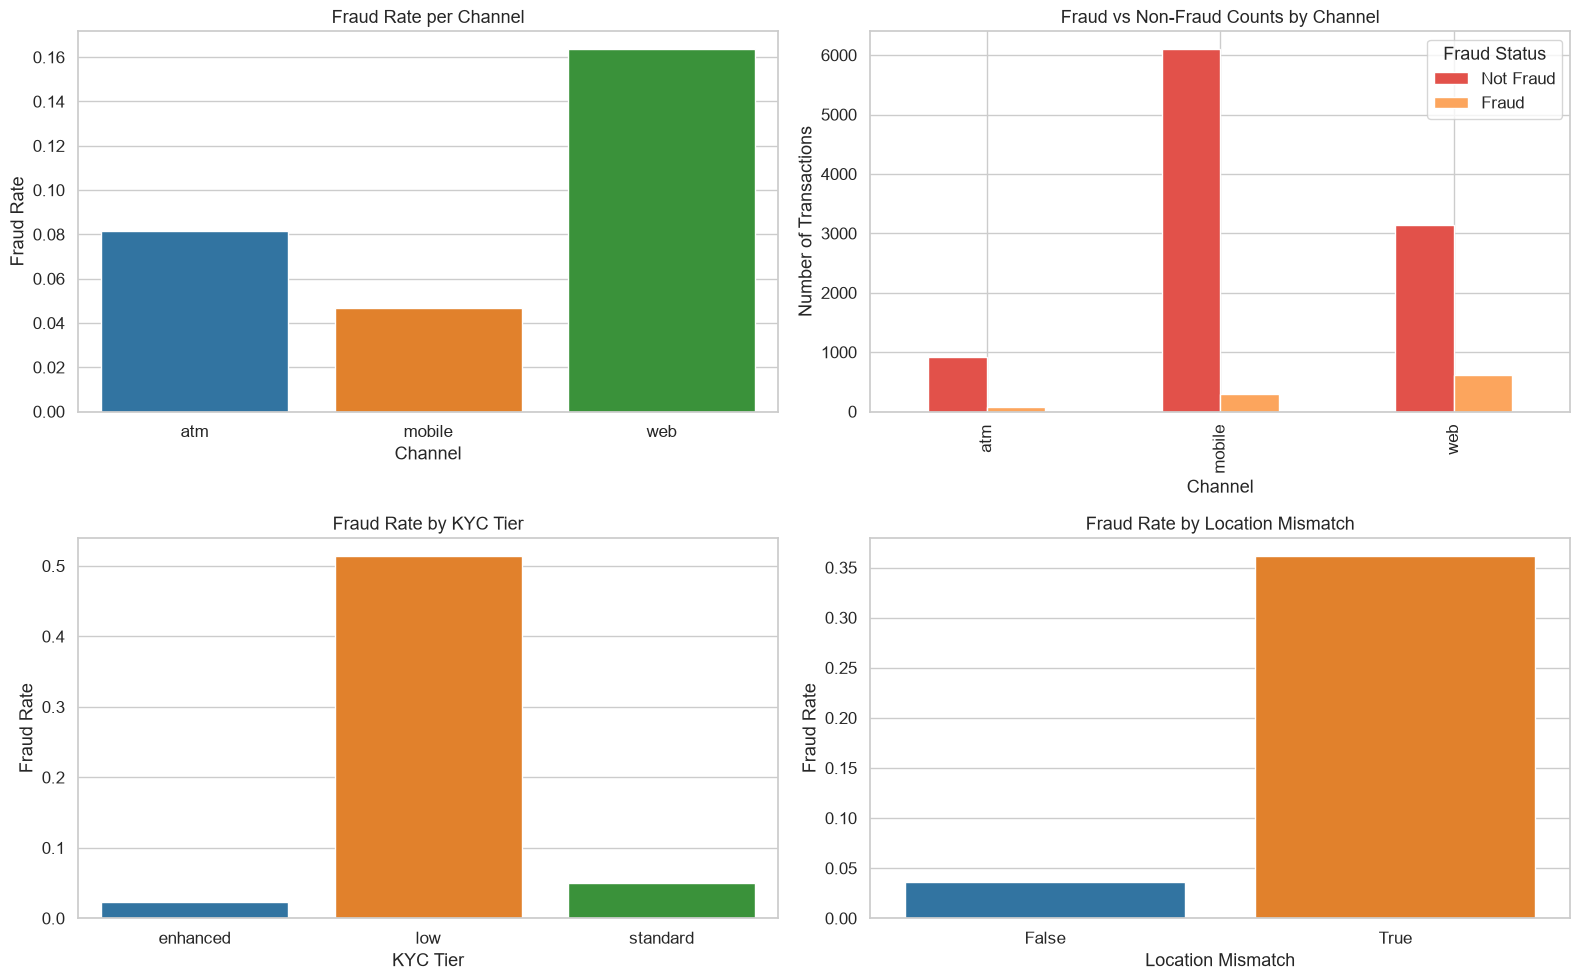

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud rate per channel
channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()

sns.barplot(
    data=channel_fraud_rate,
    x='channel',
    y='is_fraud',
    ax=axes[0, 0],
    palette='tab10'
)
axes[0, 0].set_title('Fraud Rate per Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate')

# 2. Fraud vs Non-Fraud counts per channel
channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
channel_counts = channel_counts.rename(columns={0: 'Not Fraud', 1: 'Fraud'})

channel_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Fraud vs Non-Fraud Counts by Channel')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend(title='Fraud Status')

# 3. Fraud rate per KYC tier
kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud',
    ax=axes[1, 0],
    palette='tab10'
)
axes[1, 0].set_title('Fraud Rate by KYC Tier')
axes[1, 0].set_xlabel('KYC Tier')
axes[1, 0].set_ylabel('Fraud Rate')

# 4. Fraud rate per location mismatch
location_fraud_rate = (
    cleaned_customer_transaction_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=location_fraud_rate,
    x='location_mismatch',
    y='is_fraud',
    ax=axes[1, 1],
    palette='tab10'
)
axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

In [14]:
print(channel_fraud_rate)
print(kyc_fraud_rate)
print(location_fraud_rate)

  channel  is_fraud
0     atm  0.081325
1  mobile  0.046755
2     web  0.163510
   kyc_tier  is_fraud
0  enhanced  0.022404
1       low  0.513902
2  standard  0.050321
   location_mismatch  is_fraud
0              False  0.036044
1               True  0.361386


### Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

The charts above show how fraud rate varies across `location_mismatch`, `kyc_tier`, and `channel`. Transactions where `location_mismatch = False` have a fraud rate of **3.6%**, while transactions where `location_mismatch = True` have a fraud rate of **36.1%**, roughly **10x higher**. This is one of the strongest signals found in this dataset so far and makes `location_mismatch` a strong candidate feature for the model.

`kyc_tier` shows an even sharper split: fraud rate is **2.2%** for `enhanced`, **5.0%** for `standard`, and **51.4%** for `low`, meaning over half of low-KYC-tier transactions are fraudulent, roughly **23x** the enhanced-tier rate. This is the single sharpest signal identified in the EDA so far and should be a priority feature going into modelling.

`channel` shows a real but comparatively weaker pattern: fraud rate is **16.4%** for `web`, **8.1%** for `atm`, and **4.7%** for `mobile`. Web transactions are about **3.5x** more fraud-prone than mobile ones. Raw counts should still be read alongside rate, since mobile carries by far the largest transaction volume despite its low rate.

Overall, `location_mismatch`, `kyc_tier`, and `channel` all carry meaningful fraud signal, with `kyc_tier` and `location_mismatch` standing out as the strongest, and should be carried into feature engineering and model development.

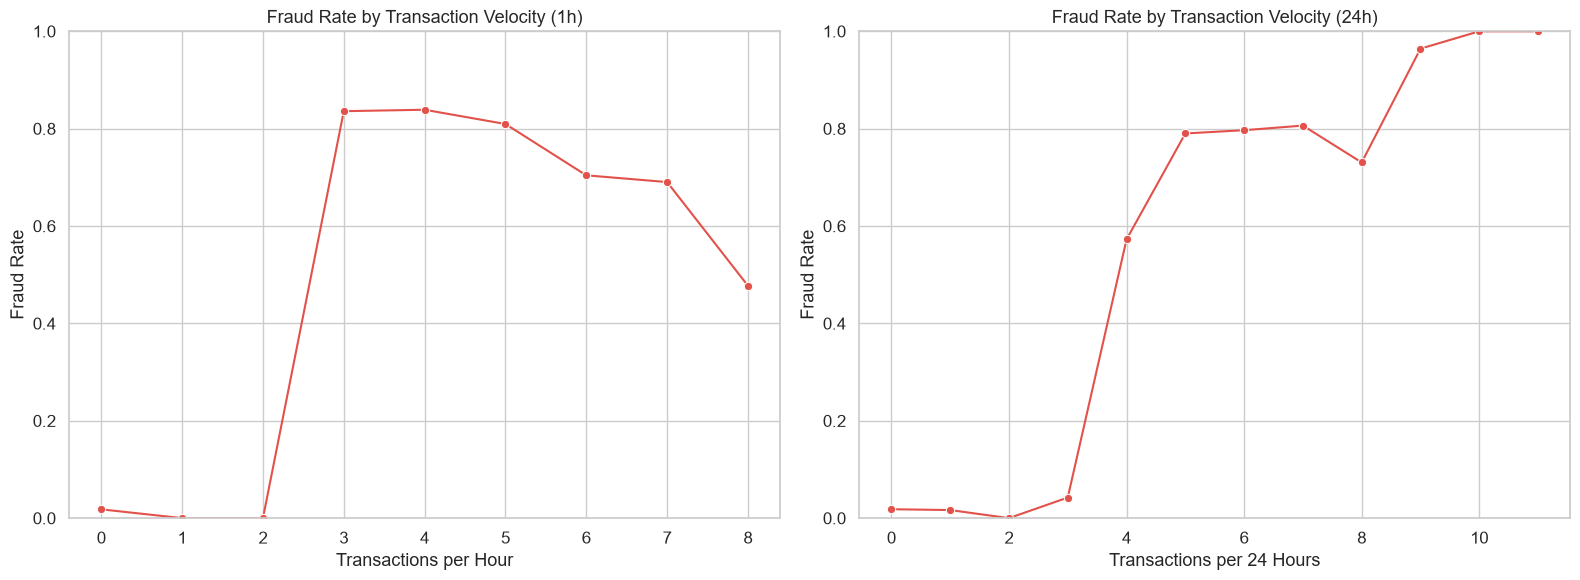

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Fraud rate by transaction velocity (1 hour)
txn_velocity_1h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1h,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Fraud Rate by Transaction Velocity (1h)')
axes[0].set_xlabel('Transactions per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)

# 2. Fraud rate by transaction velocity (24 hours)
txn_velocity_24h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Fraud Rate by Transaction Velocity (24h)')
axes[1].set_xlabel('Transactions per 24 Hours')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
cleaned_customer_transaction_data['txn_velocity_24h'].value_counts().sort_index()

txn_velocity_24h
0     9019
1      844
2      166
3       71
4      138
5      162
6      251
7      191
8      167
9       84
10      28
11      19
Name: count, dtype: int64

In [17]:
velocity_1h_summary = (
    cleaned_customer_transaction_data
    .groupby('txn_velocity_1h')['is_fraud']
    .agg(fraud_rate='mean', n='count')
    .reset_index()
)
print(velocity_1h_summary)

velocity_24h_summary = (
    cleaned_customer_transaction_data
    .groupby('txn_velocity_24h')['is_fraud']
    .agg(fraud_rate='mean', n='count')
    .reset_index()
)
print(velocity_24h_summary)

   txn_velocity_1h  fraud_rate     n
0              0.0    0.018032  9927
1              1.0    0.000000   132
2              2.0    0.000000    18
3              3.0    0.835878   262
4              4.0    0.838843   242
5              5.0    0.809524   189
6              6.0    0.704142   169
7              7.0    0.690265   113
8              8.0    0.477273    88
    txn_velocity_24h  fraud_rate     n
0                  0    0.018295  9019
1                  1    0.016588   844
2                  2    0.000000   166
3                  3    0.042254    71
4                  4    0.572464   138
5                  5    0.790123   162
6                  6    0.796813   251
7                  7    0.806283   191
8                  8    0.730539   167
9                  9    0.964286    84
10                10    1.000000    28
11                11    1.000000    19


### Transaction Velocity and Fraud Risk

For **1-hour transaction velocity**, the baseline fraud rate is low, 1.8% at 0 transactions per hour, covering the large majority of the data (n=9,927). A sharp jump occurs at 3 transactions per hour, where fraud rate rises to 83.6% (n=262), staying elevated between 69% and 84% through 7 transactions per hour, before declining to 47.7% at 8 transactions per hour (n=88). These sample sizes are large enough, over 100 transactions in most buckets, to treat this as a reliable signal rather than noise.

For **24-hour transaction velocity**, the pattern is similar but builds more gradually. Fraud rate stays low through 0 to 3 transactions per day (1.8% down to 4.2%, covering roughly 91% of the dataset), then rises to 57.2% at 4 transactions per day and climbs to 73 to 81% between 5 and 8 transactions per day. Beyond that, fraud rate reaches 96.4% at 9 transactions per day and 100% at 10 and 11 transactions per day, though these top two buckets are small (n=28 and n=19) and should be read as a strong directional signal rather than a precise rate.

Overall, both time windows show the same pattern: low transaction frequency, which describes the large majority of the dataset, corresponds to low fraud rates, while unusually high transaction frequency corresponds to sharply elevated fraud rates. `txn_velocity_1h` and `txn_velocity_24h` are strong candidate features for the model, comparable in strength to `kyc_tier` and `location_mismatch` as the clearest signals identified in this EDA.

C:\Users\hp\AppData\Local\Temp\ipykernel_13748\2616931842.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


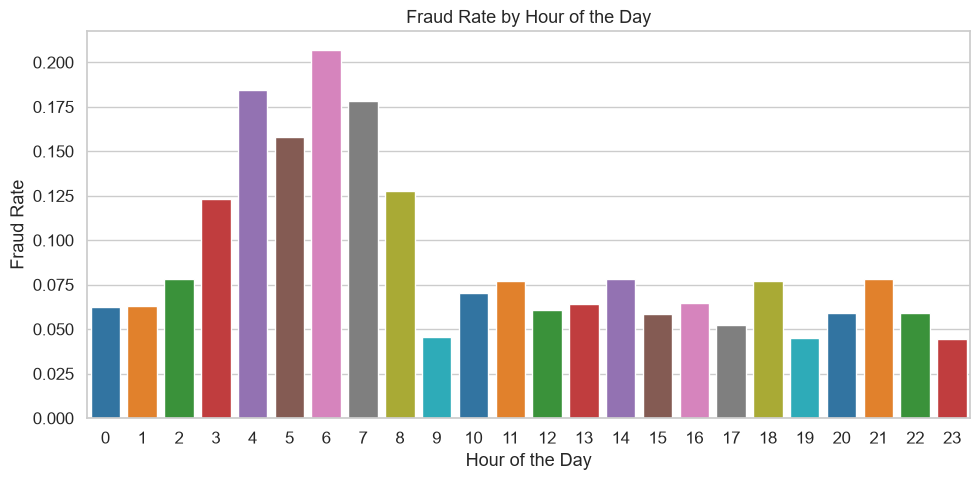

In [18]:
# converting timestamp to a real datetime type so we can extract time-based features from it
cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(cleaned_customer_transaction_data['timestamp'])

# extracting hour, day of week, weekend flag, and month from the timestamp
cleaned_customer_transaction_data['hour'] = cleaned_customer_transaction_data['timestamp'].dt.hour
cleaned_customer_transaction_data['day_of_week'] = cleaned_customer_transaction_data['timestamp'].dt.dayofweek
cleaned_customer_transaction_data['is_weekend'] = (cleaned_customer_transaction_data['day_of_week'] >= 5).astype(int)
cleaned_customer_transaction_data['month'] = cleaned_customer_transaction_data['timestamp'].dt.month

# fraud rate by hour of day
fraud_rate_by_hour = (
    cleaned_customer_transaction_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# plotting fraud rate across each hour of the day, to check whether fraud clusters at certain times
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_hour,
    x='hour',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.tight_layout()
plt.show()

In [19]:
# checking sample size per hour, to confirm the fraud-rate spike above isn't driven by a small bucket
cleaned_customer_transaction_data['hour'].value_counts().sort_index()

hour
0     465
1     414
2     421
3     495
4     509
5     487
6     478
7     460
8     485
9     438
10    469
11    441
12    460
13    468
14    436
15    480
16    464
17    439
18    481
19    509
20    456
21    435
22    456
23    494
Name: count, dtype: int64

In [20]:
hour_summary = (
    cleaned_customer_transaction_data
    .groupby('hour')['is_fraud']
    .agg(fraud_rate='mean', n='count')
    .reset_index()
)
print(hour_summary)

    hour  fraud_rate    n
0      0    0.062366  465
1      1    0.062802  414
2      2    0.078385  421
3      3    0.123232  495
4      4    0.184676  509
5      5    0.158111  487
6      6    0.207113  478
7      7    0.178261  460
8      8    0.127835  485
9      9    0.045662  438
10    10    0.070362  469
11    11    0.077098  441
12    12    0.060870  460
13    13    0.064103  468
14    14    0.077982  436
15    15    0.058333  480
16    16    0.064655  464
17    17    0.052392  439
18    18    0.076923  481
19    19    0.045187  509
20    20    0.059211  456
21    21    0.078161  435
22    22    0.059211  456
23    23    0.044534  494


### Fraud Rate by Hour of the Day

Fraud rate shows a clear elevation during the early morning hours. Between 3am and 8am, fraud rate ranges from 12.3% to 20.7%, peaking at 6am (20.7%, n=478). Outside this window, fraud rate stays in a flat band between roughly 4.5% and 7.8% across the remaining 18 hours of the day, averaging around 6.3%. This means the 3am to 8am window runs at roughly 2 to 3 times the fraud rate of the rest of the day, a pattern consistent with fraud activity concentrated during periods of lower account monitoring. Every hourly bucket has a comparable sample size, between 414 and 509 transactions, so this pattern reflects a genuine trend rather than a small-sample artifact.

Given this, `hour` (or a derived `is_night_hours` flag covering 3am to 8am) is a strong candidate feature for the model, joining `kyc_tier`, `location_mismatch`, `txn_velocity_1h`, and `txn_velocity_24h` as the clearest fraud signals identified in this EDA.

In [22]:
# confirming account_age_days never exceeds the top bin edge (2000), so pd.cut isn't silently dropping any rows into NaN
cleaned_customer_transaction_data['account_age_days'].max()

np.int64(1095)

C:\Users\hp\AppData\Local\Temp\ipykernel_13748\4292799355.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


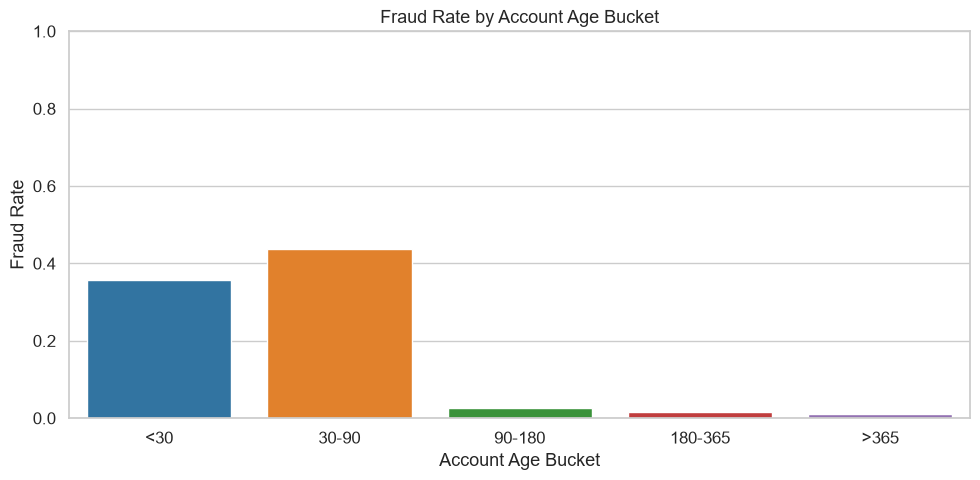

In [23]:
# creating account age buckets: <30, 30-90, 90-180, 180-365, and >365 days old
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30', '30-90', '90-180', '180-365', '>365']
)

# fraud rate by account age bucket
fraud_rate_by_account_age = (
    cleaned_customer_transaction_data.groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# plotting fraud rate across account age buckets
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_account_age,
    x='account_age_bucket',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0, 1)
plt.title('Fraud Rate by Account Age Bucket')

plt.tight_layout()
plt.show()

In [24]:
# exact fraud rate and sample size per account age bucket
account_age_summary = (
    cleaned_customer_transaction_data
    .groupby('account_age_bucket', observed=True)['is_fraud']
    .agg(fraud_rate='mean', n='count')
    .reset_index()
)
print(account_age_summary)

  account_age_bucket  fraud_rate     n
0                <30    0.355789  1900
1              30-90    0.437647   425
2             90-180    0.025176   993
3            180-365    0.016940  3601
4               >365    0.010661  4221


### Fraud Rate by Account Age Bucket

Account age shows the strongest relationship with fraud found in this EDA. Fraud rate is 35.6% for accounts under 30 days old and peaks at 43.8% for accounts 30 to 90 days old. It then drops sharply to 2.5% for 90 to 180 days, 1.7% for 180 to 365 days, and 1.1% for accounts over a year old. Accounts under 90 days old are fraudulent at roughly 33 to 41 times the rate of accounts over a year old. Every bucket has a solid sample size, from 425 to 4,221 transactions, so this pattern is reliable rather than a small-sample artifact.

This is consistent with fraud typically concentrating in newly created or recently taken-over accounts, and makes `account_age_bucket` (or `account_age_days` directly) the single strongest candidate feature identified so far, ahead of `kyc_tier`, `location_mismatch`, transaction velocity, and hour of day.

device_trust_score buckets:
device_trust_score_bucket  fraud_rate    n
                     <0.3    0.849791  719
                  0.3-0.5    0.111421 1795
                  0.5-0.7    0.021053 3230
                  0.7-0.9    0.032851 2831
                     >0.9    0.008187 2565 

ip_risk_score buckets:
ip_risk_score_bucket  fraud_rate    n
                <0.2    0.015261 2621
             0.2-0.4    0.019428 4478
             0.4-0.6    0.022118 2125
             0.6-0.8    0.085288  469
                >0.8    0.538355 1447 

amount_usd buckets:
amount_usd_bucket  fraud_rate    n
            <$250    0.029570 7609
         $250-500    0.110273 2122
          $500-1k    0.289316  833
           $1k-5k    0.740113  354
          $5k-10k    0.136842  190
            >$10k    0.156250   32 



C:\Users\hp\AppData\Local\Temp\ipykernel_13748\2787608913.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13748\2787608913.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_13748\2787608913.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


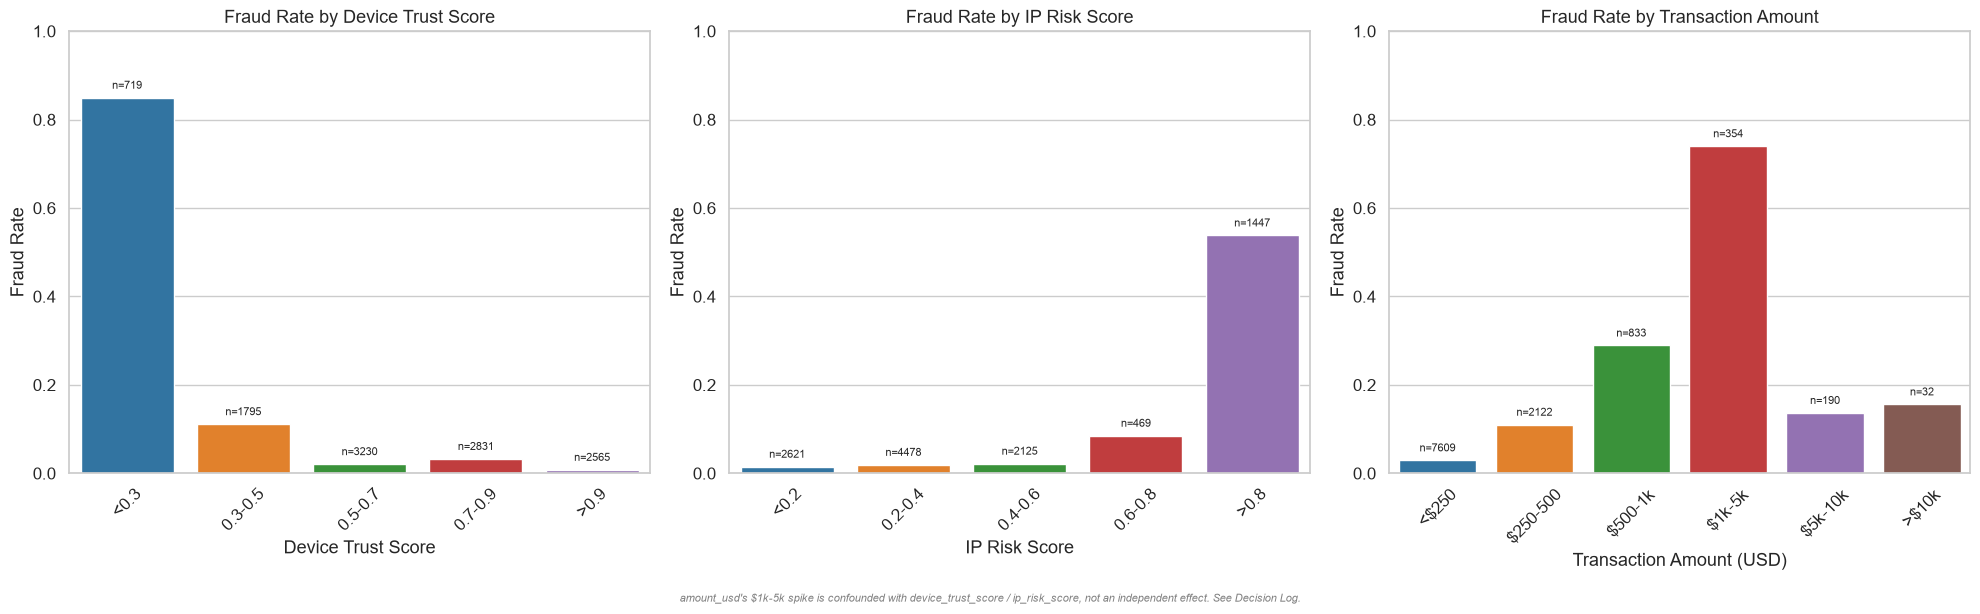

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, np.inf],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)

fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data.groupby(
        'device_trust_score_bucket',
        observed=True
    )['is_fraud']
    .agg(fraud_rate='mean', n='size')
    .reset_index()
)
print("device_trust_score buckets:")
print(fraud_rate_by_device_trust_score.to_string(index=False), "\n")

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='fraud_rate',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].tick_params(axis='x', rotation=45)
for i, row in fraud_rate_by_device_trust_score.iterrows():
    axes[0].text(i, row['fraud_rate'] + 0.02, f"n={row['n']}", ha='center', fontsize=8)

# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, np.inf],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)

fraud_rate_by_ip_risk_score = (
    cleaned_customer_transaction_data.groupby(
        'ip_risk_score_bucket',
        observed=True
    )['is_fraud']
    .agg(fraud_rate='mean', n='size')
    .reset_index()
)
print("ip_risk_score buckets:")
print(fraud_rate_by_ip_risk_score.to_string(index=False), "\n")

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='fraud_rate',
    ax=axes[1],
    palette='tab10'
)

axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].tick_params(axis='x', rotation=45)
for i, row in fraud_rate_by_ip_risk_score.iterrows():
    axes[1].text(i, row['fraud_rate'] + 0.02, f"n={row['n']}", ha='center', fontsize=8)

# 3. Fraud Rate by Transaction Amount
# Note: the $1k-5k spike here is confounded with device_trust_score and
# ip_risk_score (verified via cross-tab, see Decision Log). It is not an
# independent amount effect, kept in this EDA figure because it is a real,
# observed relationship worth seeing, not because amount drives it alone.

cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, np.inf],
    labels=[
        '<$250',
        '$250-500',
        '$500-1k',
        '$1k-5k',
        '$5k-10k',
        '>$10k'
    ],
    include_lowest=True
)

fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data.groupby(
        'amount_usd_bucket',
        observed=True
    )['is_fraud']
    .agg(fraud_rate='mean', n='size')
    .reset_index()
)
print("amount_usd buckets:")
print(fraud_rate_by_amount_usd.to_string(index=False), "\n")

sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='fraud_rate',
    ax=axes[2],
    palette='tab10'
)

axes[2].set_xlabel('Transaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0, 1)
axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].tick_params(axis='x', rotation=45)
for i, row in fraud_rate_by_amount_usd.iterrows():
    axes[2].text(i, row['fraud_rate'] + 0.02, f"n={row['n']}", ha='center', fontsize=8)

# Final layout

fig.text(
    0.5, -0.02,
    "amount_usd's $1k-5k spike is confounded with device_trust_score / ip_risk_score, "
    "not an independent effect. See Decision Log.",
    ha='center', fontsize=8, style='italic', color='gray'
)
plt.tight_layout()
plt.show()

## Fraud Rate by Device Trust Score, IP Risk Score, and Transaction Amount

Bucketed `device_trust_score`, `ip_risk_score`, and `amount_usd` with `pd.cut` and computed the fraud rate per bucket, with sample size (`n`) checked at every bucket before drawing conclusions.

**Device Trust Score** is the strongest signal found in the EDA so far. Fraud rate falls from 85.0% at `device_trust_score < 0.3` (n=719) to 0.8% at `> 0.9` (n=2,565), roughly a 104x gap, with a well-sampled lead bucket.

**IP Risk Score** shows a similar but smaller gap: 53.8% at `ip_risk_score > 0.8` (n=1,447) versus 1.5% at `< 0.2` (n=2,621), roughly 35x.

**Transaction Amount** is non-monotonic, peaking at 74.0% in the `$1k-5k` bucket (n=354) before dropping back down for larger amounts. Cross-tabbing that bucket against `device_trust_score` and `ip_risk_score` showed it is disproportionately made up of transactions those two signals had already flagged as high-risk (8.14x and 5.55x over-representation respectively), and the elevated fraud rate mostly collapses once trust or risk score is controlled for. `amount_usd` is not treated as an independent predictor here; it is being carried forward as a candidate interaction feature for modelling instead.

In [ ]:
# Check shape before export
cleaned_customer_transaction_data.shape

(11140, 34)

In [29]:
# drop EDA-only bucket columns before export, not model features yet
eda_export_data = cleaned_customer_transaction_data.drop(
    columns=[
        'account_age_bucket',
        'device_trust_score_bucket',
        'ip_risk_score_bucket',
        'amount_usd_bucket'
    ]
)

In [30]:
# sanity check: confirm row count and bucket columns are gone
eda_export_data.shape
eda_export_data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend', 'month'],
      dtype='object')

In [31]:
# export the deliberate feature set
eda_export_data.to_csv(r'../Finlora_Dataset/artifacts/EDA_Data.csv', index=False)

## EDA Summary

Explored fraud rate across the cleaned dataset (11,140 rows) using bucketed comparisons on the strongest available features. Ranked signals, strongest to weakest: `device_trust_score` (~104x gap between low- and high-trust buckets), `account_age` (~41x), `ip_risk_score` (~35x), `kyc_tier` (~23x), `txn_velocity` (up to ~84x at high hourly rates, thin at the very tail), `location_mismatch` (~10x), and hour of day (~2-3x). `channel` and `ip_country` showed real but weak effects.

`amount_usd` was investigated separately. Its apparent fraud-rate spike at $1k-5k turned out to be confounded with `device_trust_score` and `ip_risk_score`, not an independent effect, so it was left off the ranked list and is being carried forward as a candidate interaction feature instead of a standalone one.

Exported the cleaned dataset to `EDA_Data.csv`, 11,140 rows and a deliberate 30-column feature set, EDA bucket columns dropped before export, for use in the modelling phase.